## Abstract for Presentation

This notebook benchmarks sustainability classification models on the updated processed dataset and compares performance with efficiency constraints.
It includes train/test evaluation, training-time and inference-time computation, SHAP-based explainability, and deployment-ready artifact export.
Additional visual diagnostics include train-vs-validation learning curves and spiral-net (radar) accuracy-oriented comparison for individual models.

# 03 - Sustainability Classification

**Owner:** Shravya

---

### Purpose
- Train and benchmark sustainability classification models on the processed dataset.
- Select the best model under quality + efficiency criteria.
- Generate SHAP-based explanations for audit-ready interpretation.
- Save the final model bundle and evaluation metrics.

### Input
| File | Path |
|------|------|
| Processed dataset | `data/processed/final_dataset.csv` |

### Outputs
| File | Path | Description |
|------|------|-------------|
| Trained model bundle | `models/sustainability_model.pkl` | MLP (`Sequential`) + preprocessor + label encoder |
| Metrics | `results/sustainability_metrics.csv` | Accuracy, F1, Precision, Recall across tested models |
| Summary | `results/sustainability_results_summary.txt` | Best-model summary and saved chart references |

### For Colab Users
```python
# After training, save and download:
import joblib
bundle = {"model": model, "preprocessor": preprocessor, "label_encoder": label_encoder}
joblib.dump(bundle, "sustainability_model.pkl")
# Then upload .pkl to models/ and .csv/.txt to results/ on GitHub
```

In [1]:
# ============================================================
# IMPORTS + RUNTIME SETTINGS (faster + quieter on Windows)
# ============================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import warnings
warnings.filterwarnings("ignore", message=".*add_reader family of methods required for zmq.*")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from xgboost import XGBClassifier
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# Lighter training config to avoid notebook stalls during presentation reruns.
FAST_EPOCHS = {"MLP": 12, "1D CNN": 10, "GRU": 8, "LSTM": 8, "CNN-LSTM": 8}
BATCH_SIZE = 64
EARLY_STOP = EarlyStopping(monitor="val_accuracy", mode="max", patience=2, restore_best_weights=True)

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
# If running in Colab, upload final_dataset.csv or mount drive
# DATA_PATH = "final_dataset.csv"          # Colab
DATA_PATH = os.path.join("..", "data", "processed", "final_dataset.csv")  # Local

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11657, 9)


,country,year,production,water_Salinity (ppt),water_pH,water_SecchiDepth (m),water_WaterDepth (m),water_WaterTemp (C),water_AirTemp (C)
0,Afghanistan,1969,60.0,0.228486,0.105062,-0.082553,-0.014603,-0.016665,-0.01527
1,Afghanistan,1970,60.0,0.228486,0.105062,-0.082553,-0.014603,-0.016665,-0.01527
2,Afghanistan,1971,60.0,0.228486,0.105062,-0.082553,-0.014603,-0.016665,-0.01527
3,Afghanistan,1972,60.0,0.228486,0.105062,-0.082553,-0.014603,-0.016665,-0.01527
4,Afghanistan,1973,60.0,0.228486,0.105062,-0.082553,-0.014603,-0.016665,-0.01527


In [3]:
# ============================================================
# SUSTAINABILITY SCORE (official water quality features only)
# ============================================================
# The official climate extract has no production-year overlap and is excluded.
# Genomic global aggregates have no production-compatible join key and are excluded.
cols = [
    "water_pH",
    "water_Salinity (ppt)",
    "water_SecchiDepth (m)",
    "water_WaterDepth (m)",
    "water_WaterTemp (C)",
    "water_AirTemp (C)",
]
df_feat = df[cols].copy()

# STEP 2: Clean column names
df_feat = df_feat.rename(
    columns={
        "water_Salinity (ppt)": "salinity",
        "water_pH": "ph",
        "water_SecchiDepth (m)": "secchi_depth",
        "water_WaterDepth (m)": "water_depth",
        "water_WaterTemp (C)": "water_temp",
        "water_AirTemp (C)": "air_temp",
    }
)

# STEP 3: Handle missing values (mean)
for c in df_feat.columns:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")
    df_feat[c] = df_feat[c].fillna(df_feat[c].mean())

if df_feat.isna().any().any():
    raise ValueError("NaN values remain after mean imputation.")

# STEP 4: Normalize features (min-max)
ranges = {}
for c in df_feat.columns:
    min_val = df_feat[c].min()
    max_val = df_feat[c].max()
    if min_val == max_val:
        df_feat[c] = 0.5
        ranges[c] = 1.0
    else:
        df_feat[c] = (df_feat[c] - min_val) / (max_val - min_val)
        ranges[c] = max_val - min_val

# STEP 5: Convert water-quality measurements into suitability scores (0-1)
ph_range = ranges["ph"]
salinity_range = ranges["salinity"]
water_temp_range = ranges["water_temp"]
air_temp_range = ranges["air_temp"]
water_depth_range = ranges["water_depth"]

optimal_salinity = df["water_Salinity (ppt)"].mean()
optimal_temp = df["water_WaterTemp (C)"].mean()

scores = pd.DataFrame(index=df.index)
scores["ph_score"] = 1 - (df["water_pH"] - 7.5).abs() / ph_range
scores["salinity_score"] = 1 - (df["water_Salinity (ppt)"] - optimal_salinity).abs() / salinity_range
scores["secchi_score"] = df_feat["secchi_depth"]
scores["water_depth_score"] = df_feat["water_depth"]
scores["water_temp_score"] = 1 - (df["water_WaterTemp (C)"] - optimal_temp).abs() / water_temp_range
scores["air_temp_score"] = 1 - (df["water_AirTemp (C)"] - optimal_temp).abs() / air_temp_range

scores = scores.clip(0, 1)
df = pd.concat([df, scores], axis=1)

print("Created water-quality suitability score columns:")
print(list(scores.columns))
df[scores.columns].head()

Created water-quality suitability score columns:
['ph_score', 'salinity_score', 'secchi_score', 'water_depth_score', 'water_temp_score', 'air_temp_score']


,ph_score,salinity_score,secchi_score,water_depth_score,water_temp_score,air_temp_score
0,0.0,1.0,0.424503,0.363537,1.0,0.99888
1,0.0,1.0,0.424503,0.363537,1.0,0.99888
2,0.0,1.0,0.424503,0.363537,1.0,0.99888
3,0.0,1.0,0.424503,0.363537,1.0,0.99888
4,0.0,1.0,0.424503,0.363537,1.0,0.99888


In [4]:
# ============================================================
# TARGET DEFINITION (independent from feature-engineered scores)
# ============================================================
# NOTE:
# The previous target definition used sustainability_score computed from
# the same water/climate predictors, which can make model accuracy appear
# unrealistically perfect. Use an independent proxy target instead.

TARGET_COL = "sustainability_class"

df[TARGET_COL] = pd.qcut(
    df["production"],
    q=3,
    labels=["Low", "Medium", "High"],
).astype(str)

print("Created sustainability_class from production quantiles (independent target).")
print(df[TARGET_COL].value_counts(dropna=False))
df[["production", TARGET_COL]].head()

Created sustainability_class from production quantiles (independent target).
sustainability_class
Low       3899
High      3886
Medium    3872
Name: count, dtype: int64


,production,sustainability_class
0,60.0,Low
1,60.0,Low
2,60.0,Low
3,60.0,Low
4,60.0,Low


In [5]:
# ============================================================
# FEATURE / TARGET SPLIT (leakage-safe)
# ============================================================
TARGET_COL = "sustainability_class"

# Drop all target-like and score-derived columns from features.
leakage_cols = [
    "sustainability_class",
    "sustainability_score",
] + [c for c in df.columns if c.endswith("_score")]

X = df.drop(columns=leakage_cols, errors="ignore")
y = df[TARGET_COL].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Removed leakage columns: {[c for c in leakage_cols if c in df.columns]}")

X_train: (9325, 9), X_test: (2332, 9)
y_train: (9325,), y_test: (2332,)
Removed leakage columns: ['sustainability_class', 'ph_score', 'salinity_score', 'secchi_score', 'water_depth_score', 'water_temp_score', 'air_temp_score']


In [6]:
# ============================================================
# METRICS STORE (Accuracy, Precision, Recall, F1)
# ============================================================
model_metrics = {}

In [7]:
# ============================================================
# MLP (Keras) CLASSIFICATION + TIMING + EVALUATION (fast run)
# ============================================================
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
if not transformers:
    raise ValueError("No features available for encoding/scaling.")

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.0,
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

input_dim = X_train_proc.shape[1]
model = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.time()
history = model.fit(
    X_train_proc,
    y_train_enc,
    epochs=FAST_EPOCHS["MLP"],
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[EARLY_STOP],
    verbose=0,
)
train_time = time.time() - start_time

test_loss, test_acc = model.evaluate(X_test_proc, y_test_enc, verbose=0)
y_pred_enc = model.predict(X_test_proc, verbose=0).argmax(axis=1)

mlp_prec = precision_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
mlp_rec = recall_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
mlp_f1 = f1_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
model_metrics["MLP"] = {
    "accuracy": test_acc,
    "precision": mlp_prec,
    "recall": mlp_rec,
    "f1": mlp_f1,
}

print(f"Training time (s): {train_time:.2f}")
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_test_enc, y_pred_enc, target_names=label_encoder.classes_))

C:\Users\Khushi Chandak\AppData\Local\Temp\ipykernel_4220\3666780971.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


Training time (s): 3.89
Test accuracy: 0.9511
              precision    recall  f1-score   support

        High       0.97      0.98      0.97       777
         Low       0.94      0.97      0.95       780
      Medium       0.94      0.91      0.93       775

    accuracy                           0.95      2332
   macro avg       0.95      0.95      0.95      2332
weighted avg       0.95      0.95      0.95      2332



In [8]:
# ============================================================
# SAVE SUSTAINABILITY MODEL (MLP) TO .PKL
# ============================================================
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "sustainability_model.pkl")

# Save model + preprocessing + label encoder together
joblib.dump(
    {"model": model, "preprocessor": preprocessor, "label_encoder": label_encoder},
    model_path,
)
print(f"Saved model bundle to: {model_path}")

Saved model bundle to: ..\models\sustainability_model.pkl


In [9]:
# ============================================================
# 1D CNN (short sequence features) + TIMING + EVALUATION
# ============================================================
X_train_dense = np.asarray(X_train_proc)
X_test_dense = np.asarray(X_test_proc)

X_train_cnn = X_train_dense.reshape(X_train_dense.shape[0], X_train_dense.shape[1], 1)
X_test_cnn = X_test_dense.reshape(X_test_dense.shape[0], X_test_dense.shape[1], 1)

cnn_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_cnn.shape[1], 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_start = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_enc,
    epochs=FAST_EPOCHS["1D CNN"],
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[EARLY_STOP],
    verbose=0,
)
cnn_train_time = time.time() - cnn_start

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_enc, verbose=0)
cnn_pred = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)

cnn_prec = precision_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
cnn_rec = recall_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
cnn_f1 = f1_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
model_metrics["1D CNN"] = {
    "accuracy": cnn_acc,
    "precision": cnn_prec,
    "recall": cnn_rec,
    "f1": cnn_f1,
}

print(f"CNN training time (s): {cnn_train_time:.2f}")
print(f"CNN test accuracy: {cnn_acc:.4f}")
print(classification_report(y_test_enc, cnn_pred, target_names=label_encoder.classes_))

CNN training time (s): 3.62
CNN test accuracy: 0.4112
              precision    recall  f1-score   support

        High       0.52      0.22      0.30       777
         Low       0.40      0.59      0.47       780
      Medium       0.39      0.43      0.41       775

    accuracy                           0.41      2332
   macro avg       0.43      0.41      0.40      2332
weighted avg       0.43      0.41      0.40      2332



In [10]:
# ============================================================
# GRU (single layer, lightweight) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_gru = X_train_cnn
X_test_gru = X_test_cnn

gru_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_gru.shape[1], 1)),
        layers.GRU(32),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

gru_start = time.time()
gru_history = gru_model.fit(
    X_train_gru,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
gru_train_time = time.time() - gru_start

gru_loss, gru_acc = gru_model.evaluate(X_test_gru, y_test_enc, verbose=0)
gru_pred = gru_model.predict(X_test_gru, verbose=0).argmax(axis=1)

gru_prec = precision_score(y_test_enc, gru_pred, average="macro", zero_division=0)
gru_rec = recall_score(y_test_enc, gru_pred, average="macro", zero_division=0)
gru_f1 = f1_score(y_test_enc, gru_pred, average="macro", zero_division=0)
model_metrics["GRU"] = {
    "accuracy": gru_acc,
    "precision": gru_prec,
    "recall": gru_rec,
    "f1": gru_f1,
}

print(f"GRU training time (s): {gru_train_time:.2f}")
print(f"GRU test accuracy: {gru_acc:.4f}")
print(classification_report(y_test_enc, gru_pred, target_names=label_encoder.classes_))

Epoch 1/15


  1/234 ━━━━━━━━━━━━━━━━━━━━ 4:31 1s/step - accuracy: 0.2500 - loss: 1.0979

  3/234 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.3056 - loss: 1.0978

  5/234 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.3146 - loss: 1.0981

  7/234 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.3222 - loss: 1.0981

...

229/234 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3889 - loss: 1.0484

231/234 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3890 - loss: 1.0484

233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3891 - loss: 1.0483

234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.4004 - loss: 1.0436 - val_accuracy: 0.3952 - val_loss: 1.0520


GRU training time (s): 147.11
GRU test accuracy: 0.3945
              precision    recall  f1-score   support

        High       0.38      0.84      0.52       777
         Low       0.57      0.18      0.28       780
      Medium       0.34      0.16      0.22       775

    accuracy                           0.39      2332
   macro avg       0.43      0.39      0.34      2332
weighted avg       0.43      0.39      0.34      2332



In [11]:
# ============================================================
# LSTM (single layer, low hidden units) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_lstm = X_train_cnn
X_test_lstm = X_test_cnn

lstm_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_lstm.shape[1], 1)),
        layers.LSTM(16),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

lstm_start = time.time()
lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
lstm_train_time = time.time() - lstm_start

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_enc, verbose=0)
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).argmax(axis=1)

lstm_prec = precision_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
lstm_rec = recall_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
lstm_f1 = f1_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
model_metrics["LSTM"] = {
    "accuracy": lstm_acc,
    "precision": lstm_prec,
    "recall": lstm_rec,
    "f1": lstm_f1,
}

print(f"LSTM training time (s): {lstm_train_time:.2f}")
print(f"LSTM test accuracy: {lstm_acc:.4f}")
print(classification_report(y_test_enc, lstm_pred, target_names=label_encoder.classes_))

Epoch 1/15


  1/234 ━━━━━━━━━━━━━━━━━━━━ 3:56 1s/step - accuracy: 0.1875 - loss: 1.0988

  4/234 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2826 - loss: 1.0984

  7/234 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3004 - loss: 1.0985

 10/234 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3129 - loss: 1.0986

...

226/234 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3916 - loss: 1.0778

229/234 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3917 - loss: 1.0778

232/234 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3919 - loss: 1.0777

234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4021 - loss: 1.0729 - val_accuracy: 0.4225 - val_loss: 1.0678


LSTM training time (s): 94.01
LSTM test accuracy: 0.4275
              precision    recall  f1-score   support

        High       0.41      0.48      0.44       777
         Low       0.46      0.53      0.49       780
      Medium       0.41      0.27      0.32       775

    accuracy                           0.43      2332
   macro avg       0.43      0.43      0.42      2332
weighted avg       0.43      0.43      0.42      2332



In [12]:
# ============================================================
# CNN-LSTM (lightweight) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_cnnlstm = X_train_cnn
X_test_cnnlstm = X_test_cnn

cnn_lstm_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_cnnlstm.shape[1], 1)),
        layers.Conv1D(16, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.LSTM(16),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_lstm_start = time.time()
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_cnnlstm,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
cnn_lstm_train_time = time.time() - cnn_lstm_start

cnn_lstm_loss, cnn_lstm_acc = cnn_lstm_model.evaluate(X_test_cnnlstm, y_test_enc, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test_cnnlstm, verbose=0).argmax(axis=1)

cnn_lstm_prec = precision_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
cnn_lstm_rec = recall_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
cnn_lstm_f1 = f1_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
model_metrics["CNN-LSTM"] = {
    "accuracy": cnn_lstm_acc,
    "precision": cnn_lstm_prec,
    "recall": cnn_lstm_rec,
    "f1": cnn_lstm_f1,
}

print(f"CNN-LSTM training time (s): {cnn_lstm_train_time:.2f}")
print(f"CNN-LSTM test accuracy: {cnn_lstm_acc:.4f}")
print(classification_report(y_test_enc, cnn_lstm_pred, target_names=label_encoder.classes_))

Epoch 1/15


  1/234 ━━━━━━━━━━━━━━━━━━━━ 4:52 1s/step - accuracy: 0.2500 - loss: 1.0967

  5/234 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3097 - loss: 1.0976

  9/234 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3255 - loss: 1.0978

 13/234 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3334 - loss: 1.0978

...

225/234 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4351 - loss: 1.0344

229/234 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4353 - loss: 1.0342

233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4355 - loss: 1.0339

234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4454 - loss: 1.0194 - val_accuracy: 0.4558 - val_loss: 1.0164


CNN-LSTM training time (s): 62.52
CNN-LSTM test accuracy: 0.4374
              precision    recall  f1-score   support

        High       0.42      0.61      0.50       777
         Low       0.47      0.48      0.47       780
      Medium       0.42      0.22      0.29       775

    accuracy                           0.44      2332
   macro avg       0.44      0.44      0.42      2332
weighted avg       0.44      0.44      0.42      2332



Saved comparison chart to: ..\results\sustainability_model_comparison.png


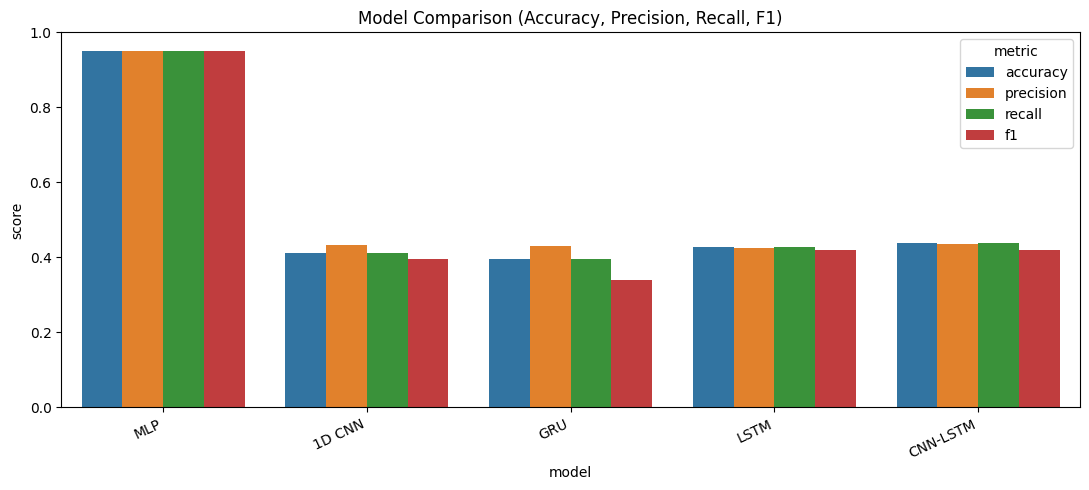

In [13]:
# ============================================================
# COMPARISON GRAPH (all 5 models in one chart)
# ============================================================
if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

model_order = ["MLP", "1D CNN", "GRU", "LSTM", "CNN-LSTM"]
metrics_df = pd.DataFrame(model_metrics).T
available = [m for m in model_order if m in metrics_df.index]
missing = [m for m in model_order if m not in metrics_df.index]
if missing:
    print(f"Missing models in metrics: {missing}. Run those model cells first.")

metrics_df = metrics_df.loc[available]

plot_df = metrics_df[["accuracy", "precision", "recall", "f1"]].reset_index().rename(columns={"index": "model"})
plot_df = plot_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="metric", loc="upper right")
plt.tight_layout()

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)
comparison_path = os.path.join(results_dir, "sustainability_model_comparison.png")
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
print(f"Saved comparison chart to: {comparison_path}")
plt.show()

## Train/Test Learning Curves + Spiral Net Accuracy View

This section adds two required visual diagnostics:
- Train vs validation accuracy trajectories for each sustainability model
- Spiral-net (radar/polar) comparison of model quality metrics, focused on accuracy prediction context

Saved train/validation curve chart to: ..\results\sustainability_train_val_curves.png


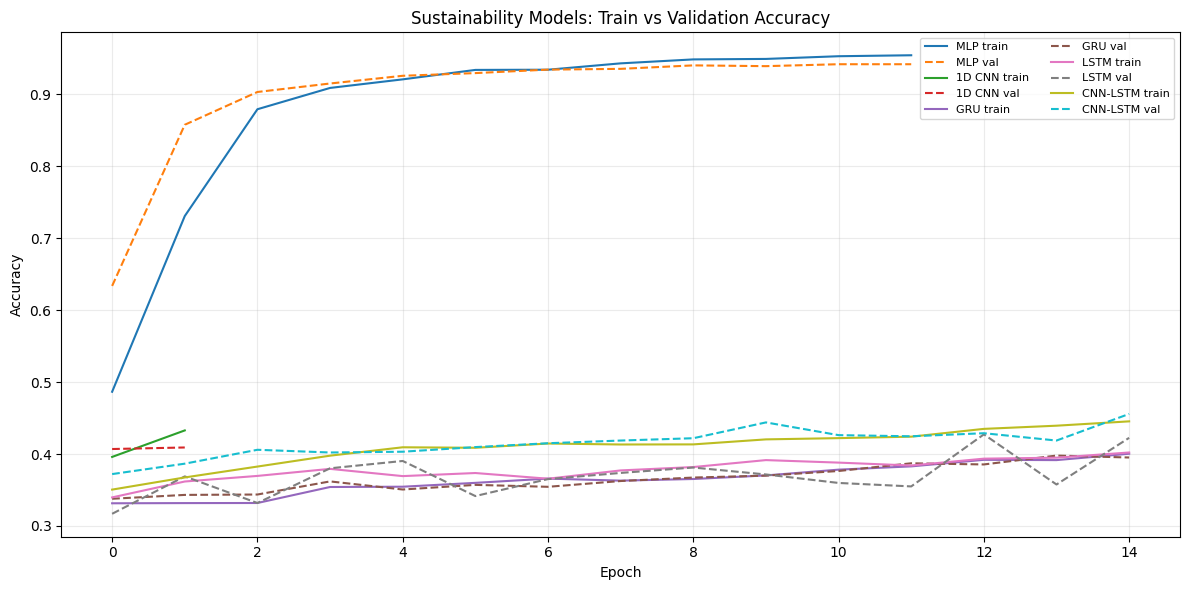

Saved spiral-net chart to: ..\results\sustainability_spiral_net_metrics.png


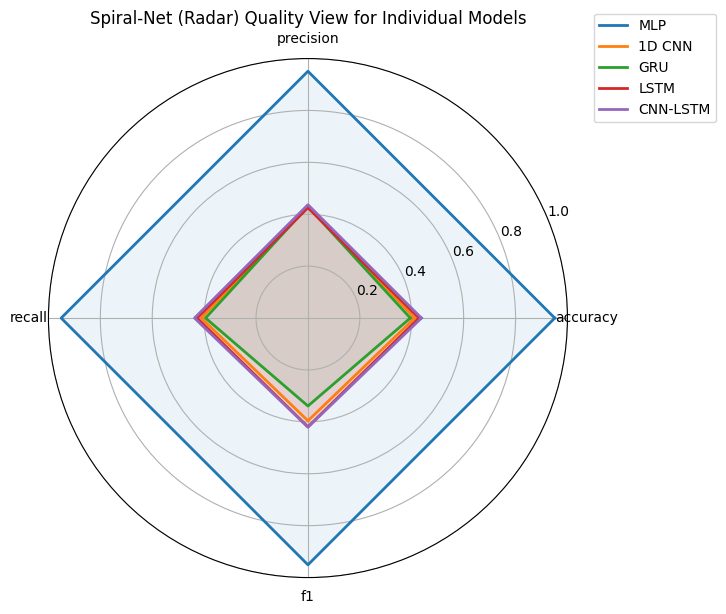

In [14]:
# ============================================================
# TRAIN vs VALIDATION CURVES + SPIRAL-NET (RADAR) METRIC VIEW
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Build learning-curve map from training histories created earlier.
history_map = {}
if "history" in globals():
    history_map["MLP"] = history
if "cnn_history" in globals():
    history_map["1D CNN"] = cnn_history
if "gru_history" in globals():
    history_map["GRU"] = gru_history
if "lstm_history" in globals():
    history_map["LSTM"] = lstm_history
if "cnn_lstm_history" in globals():
    history_map["CNN-LSTM"] = cnn_lstm_history

if history_map:
    plt.figure(figsize=(12, 6))
    for name, h in history_map.items():
        hist = h.history if hasattr(h, "history") else {}
        if "accuracy" in hist:
            plt.plot(hist["accuracy"], label=f"{name} train")
        if "val_accuracy" in hist:
            plt.plot(hist["val_accuracy"], linestyle="--", label=f"{name} val")

    plt.title("Sustainability Models: Train vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    curve_path = os.path.join("..", "results", "sustainability_train_val_curves.png")
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    print(f"Saved train/validation curve chart to: {curve_path}")
    plt.show()
else:
    print("No training histories found. Run model training cells first.")

# Spiral-net (radar) comparison of model metrics
if "model_metrics" in globals() and model_metrics:
    rad_df = pd.DataFrame(model_metrics).T[["accuracy", "precision", "recall", "f1"]].copy()
    labels = rad_df.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7.5, 7.5))
    ax = plt.subplot(111, polar=True)

    for model_name, row in rad_df.iterrows():
        vals = row.values.tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=model_name)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title("Spiral-Net (Radar) Quality View for Individual Models")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()

    spiral_path = os.path.join("..", "results", "sustainability_spiral_net_metrics.png")
    plt.savefig(spiral_path, dpi=200, bbox_inches="tight")
    print(f"Saved spiral-net chart to: {spiral_path}")
    plt.show()
else:
    print("model_metrics is empty. Run training cells first.")

Saved bubble chart to: ..\results\sustainability_inference_training_ram.png


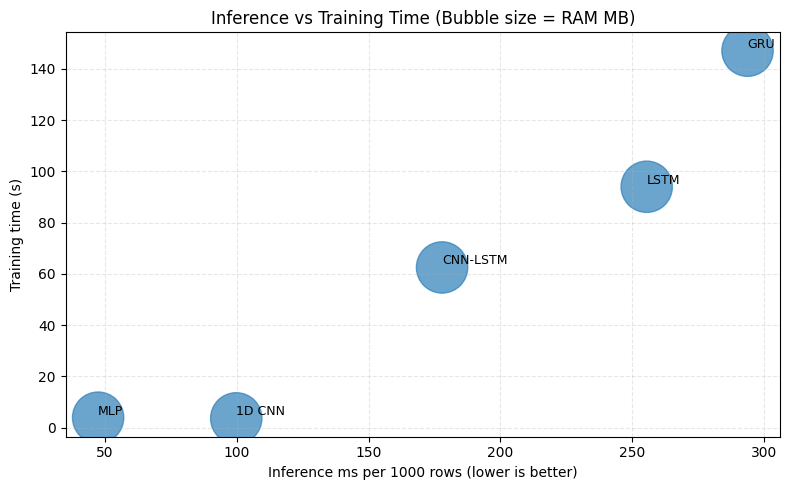

In [15]:
# ============================================================
# INFERENCE vs TRAINING TIME vs RAM (bubble chart)
# ============================================================
process = psutil.Process()

def _infer_time_ms_per_1000(model_obj, x_data):
    n = x_data.shape[0]
    if n == 0:
        return np.nan
    start = time.time()
    _ = model_obj.predict(x_data, verbose=0)
    elapsed = time.time() - start
    return (elapsed / n) * 1000 * 1000  # ms per 1000 rows

model_names = []
train_times = []
infer_ms_1k = []
ram_mb = []

# MLP
model_names.append("MLP")
train_times.append(train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(model, X_test_proc))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# 1D CNN
model_names.append("1D CNN")
train_times.append(cnn_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(cnn_model, X_test_cnn))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# GRU
model_names.append("GRU")
train_times.append(gru_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(gru_model, X_test_gru))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# LSTM
model_names.append("LSTM")
train_times.append(lstm_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(lstm_model, X_test_lstm))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# CNN-LSTM
model_names.append("CNN-LSTM")
train_times.append(cnn_lstm_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(cnn_lstm_model, X_test_cnnlstm))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

plt.figure(figsize=(8, 5))
sizes = [max(30, m) * 2 for m in ram_mb]
plt.scatter(infer_ms_1k, train_times, s=sizes, alpha=0.7, color="#2C7FB8")
for i, name in enumerate(model_names):
    plt.text(infer_ms_1k[i], train_times[i], name, fontsize=9, ha="left", va="bottom")

plt.title("Inference vs Training Time (Bubble size = RAM MB)")
plt.xlabel("Inference ms per 1000 rows (lower is better)")
plt.ylabel("Training time (s)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)
bubble_path = os.path.join(results_dir, "sustainability_inference_training_ram.png")
plt.savefig(bubble_path, dpi=200, bbox_inches="tight")
print(f"Saved bubble chart to: {bubble_path}")
plt.show()

In [16]:
# ============================================================
# SAVE METRICS + BEST MODEL SUMMARY TO RESULTS/
# ============================================================
if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)

metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values(by="accuracy", ascending=False)
metrics_path = os.path.join(results_dir, "sustainability_metrics.csv")
metrics_df.to_csv(metrics_path, index=True)
print(f"Saved metrics to: {metrics_path}")

best_model_name = metrics_df.index[0]
best_row = metrics_df.iloc[0]
best_shap_name = best_model_name.lower().replace(" ", "_").replace("-", "_")
best_shap_path = f"sustainability_shap_best_{best_shap_name}.png"
summary_lines = [
    "Sustainability Classification Results",
    "====================================",
    f"Best model: {best_model_name}",
    f"Accuracy: {best_row['accuracy']:.4f}",
    f"Precision (macro): {best_row['precision']:.4f}",
    f"Recall (macro): {best_row['recall']:.4f}",
    f"F1 (macro): {best_row['f1']:.4f}",
    "",
    "All model metrics saved in sustainability_metrics.csv",
    "Charts saved:",
    "- sustainability_model_comparison.png",
    "- sustainability_inference_training_ram.png",
    "",
    "Best-model SHAP plot:",
    f"- {best_shap_path}",
    "",
    "Model artifact:",
    "- models/sustainability_model.pkl (MLP)",
]
summary_path = os.path.join(results_dir, "sustainability_results_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))
print(f"Saved summary to: {summary_path}")

Saved metrics to: ..\results\sustainability_metrics.csv
Saved summary to: ..\results\sustainability_results_summary.txt


Best model for SHAP: MLP
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


...

  1/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

 97/157 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step


C:\Users\Khushi Chandak\AppData\Local\Temp\ipykernel_4220\565290512.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain, show=False)
D:\GitHub\Aquaculture-MajorProject\venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
D:\GitHub\Aquaculture-MajorProject\venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summa

Saved SHAP plot to: ..\results\sustainability_shap_best_mlp.png


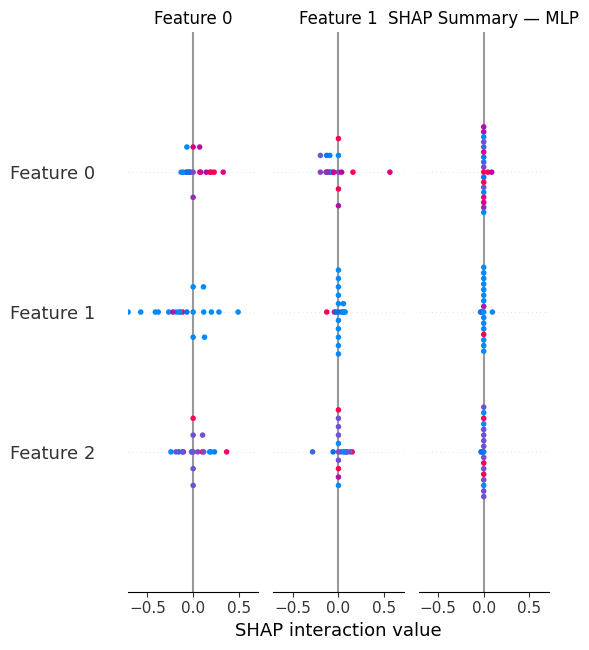

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


Most influential parameter (SHAP): f_0 (|mean SHAP|=0.114285)


In [17]:
# ============================================================
# SHAP EXPLANATIONS FOR BEST MODEL ONLY (lightweight)
# ============================================================
def _sample_rows(array_like, n):
    n = min(n, array_like.shape[0])
    idx = np.random.choice(array_like.shape[0], n, replace=False)
    return array_like[idx]

def _shap_kernel_tabular(model_predict, background, explain, title, save_path=None):
    explainer = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(explain, nsamples=100)
    shap.summary_plot(shap_values, explain, show=False)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved SHAP plot to: {save_path}")
    plt.show()
    return shap_values

def _make_seq_predictor(model_obj, timesteps):
    def _predict(flat_x):
        reshaped = flat_x.reshape(flat_x.shape[0], timesteps, 1)
        return model_obj.predict(reshaped, verbose=0)
    return _predict

def _flatten_3d(arr_3d):
    return arr_3d.reshape(arr_3d.shape[0], -1)

if not model_metrics:
    raise ValueError("model_metrics is empty. Run training cells first.")

metrics_df = pd.DataFrame(model_metrics).T
best_model_name = metrics_df["accuracy"].idxmax()
print(f"Best model for SHAP: {best_model_name}")

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)

# Prepare SHAP inputs based on the best model
if best_model_name == "MLP":
    bg = _sample_rows(X_train_proc, 50)
    explain = _sample_rows(X_test_proc, 20)
    predictor = model.predict
    title = "SHAP Summary — MLP"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_mlp.png")
    feature_names = list(X_train_proc.columns) if hasattr(X_train_proc, "columns") else [f"f_{i}" for i in range(bg.shape[1])]
elif best_model_name == "1D CNN":
    bg = _flatten_3d(_sample_rows(X_train_cnn, 30))
    explain = _flatten_3d(_sample_rows(X_test_cnn, 15))
    predictor = _make_seq_predictor(cnn_model, X_train_cnn.shape[1])
    title = "SHAP Summary — 1D CNN"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_1d_cnn.png")
    feature_names = [f"seq_feature_{i}" for i in range(bg.shape[1])]
elif best_model_name == "GRU":
    bg = _flatten_3d(_sample_rows(X_train_gru, 30))
    explain = _flatten_3d(_sample_rows(X_test_gru, 15))
    predictor = _make_seq_predictor(gru_model, X_train_gru.shape[1])
    title = "SHAP Summary — GRU"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_gru.png")
    feature_names = [f"seq_feature_{i}" for i in range(bg.shape[1])]
elif best_model_name == "LSTM":
    bg = _flatten_3d(_sample_rows(X_train_lstm, 30))
    explain = _flatten_3d(_sample_rows(X_test_lstm, 15))
    predictor = _make_seq_predictor(lstm_model, X_train_lstm.shape[1])
    title = "SHAP Summary — LSTM"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_lstm.png")
    feature_names = [f"seq_feature_{i}" for i in range(bg.shape[1])]
elif best_model_name == "CNN-LSTM":
    bg = _flatten_3d(_sample_rows(X_train_cnnlstm, 30))
    explain = _flatten_3d(_sample_rows(X_test_cnnlstm, 15))
    predictor = _make_seq_predictor(cnn_lstm_model, X_train_cnnlstm.shape[1])
    title = "SHAP Summary — CNN-LSTM"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_cnn_lstm.png")
    feature_names = [f"seq_feature_{i}" for i in range(bg.shape[1])]
else:
    raise ValueError(f"Unknown best model name: {best_model_name}")

shap_values_obj = _shap_kernel_tabular(predictor, bg, explain, title, shap_path)

# Highlight most influential parameter for audit-ready explainability.
try:
    if isinstance(shap_values_obj, list):
        pred = predictor(explain[:1])
        cls_idx = int(np.argmax(pred[0])) if np.asarray(pred).ndim > 1 else 0
        cls_idx = int(min(max(cls_idx, 0), len(shap_values_obj) - 1))
        sv = np.asarray(shap_values_obj[cls_idx], dtype=float)
    else:
        sv = np.asarray(shap_values_obj, dtype=float)
        if sv.ndim == 3:
            pred = predictor(explain[:1])
            cls_idx = int(np.argmax(pred[0])) if np.asarray(pred).ndim > 1 else 0
            cls_idx = int(min(max(cls_idx, 0), sv.shape[2] - 1))
            sv = sv[:, :, cls_idx]

    if sv.ndim == 1:
        abs_imp = np.abs(sv)
    else:
        abs_imp = np.mean(np.abs(sv), axis=0)

    top_idx = int(np.argmax(abs_imp))
    top_idx = int(min(max(top_idx, 0), len(feature_names) - 1))
    print(
        f"Most influential parameter (SHAP): {feature_names[top_idx]} "
        f"(|mean SHAP|={float(abs_imp[top_idx]):.6f})"
    )
except Exception as exc:
    print(f"Unable to derive top SHAP parameter: {exc}")

In [18]:
# Quick metrics snapshot for audit
if 'model_metrics' in globals() and model_metrics:
    print(pd.DataFrame(model_metrics).T[['accuracy', 'precision', 'recall', 'f1']].round(4))
else:
    print('model_metrics is empty. Run training cells first.')

          accuracy  precision  recall      f1
MLP         0.9511     0.9511  0.9511  0.9509
1D CNN      0.4112     0.4343  0.4110  0.3959
GRU         0.3945     0.4302  0.3946  0.3390
LSTM        0.4275     0.4250  0.4273  0.4193
CNN-LSTM    0.4374     0.4366  0.4371  0.4206


## Best Model Architecture (Sustainability) - MLP

### Architecture Diagram
Input features -> Preprocessor transform -> MLP -> Class probabilities -> SHAP interpretation

```mermaid
flowchart LR
    A[Input: climate + water + genomic aggregate features] --> B[Preprocess: scale numeric + encode categorical]
    B --> C[Model: Keras Sequential MLP]
    C --> D[Output: Low / Medium / High sustainability + softmax confidence]
    D --> E[Explainability: SHAP impacts for feature-level interpretation]
```

### 1. Input Layer
- Source dataset: `final_dataset.csv`.
- Target: production quantiles mapped to Low/Medium/High sustainability class proxy.
- Feature set: selected climate + water + genomic aggregate indicators.

### 2. Processing Layer
- Numeric features scaled before model fitting.
- Categorical fields encoded and aligned through preprocessing pipeline.
- Label encoding used for multiclass training labels.
- Train/test split uses fixed random state for reproducibility.

### 3. Model Layer (Best Performing)
- Estimator: Keras `Sequential` MLP.
- Current saved stack: `Dense(64, relu) -> Dropout(0.2) -> Dense(32, relu) -> Dense(3, softmax)`.
- Why selected: highest sustainability accuracy/F1 in current notebook benchmark.

### 4. Output Layer
- Class output: Low / Medium / High sustainability level.
- Probabilistic confidence from softmax probabilities.

### 5. Explainability Layer (SHAP)
- Kernel SHAP used for the active best model.
- SHAP summaries identify highest-impact parameters per prediction context.
- Saved SHAP plot artifacts support audit-ready interpretation.

### 6. Limitations
- Sustainability target is a proxy derived from production quantiles.
- Neural-network behavior is data-driven and can be sensitive to distribution shift.
- SHAP explains model behavior, not exact ecological causality.
- Performance may vary on unseen regions, farm systems, or extreme regimes.